# Financial Simulator for Testing Various Models and Thresholds


In [4]:
import pandas as pd
import numpy as np
from main import specialty_preprocess_df
from collections import defaultdict as dd


my_df = pd.read_csv(
    "./datasets/lc_data_2007_to_2018.csv",
    low_memory=False,
    encoding="latin1",
    nrows=100000,  # only looking at 100k rows right now for performance
)
pd.set_option("display.max_columns", None)
cleaned_df = specialty_preprocess_df(my_df)

In [6]:
cleaned_df["net_pnl"] = cleaned_df["total_pymnt"] - cleaned_df["loan_amnt"]
log_reg_preds = pd.read_csv("log_reg_predictions.csv", index_col=0)
rf_preds = pd.read_csv("rf_predictions.csv", index_col=0)

test_financials = cleaned_df.join(log_reg_preds, how="inner")
test_financials = test_financials.join(rf_preds[["rf_prob"]], how="inner")
print(
    test_financials[
        ["loan_amnt", "total_pymnt", "net_pnl", "log_reg_prob", "rf_prob"]
    ].head()
)

     loan_amnt   total_pymnt      net_pnl  log_reg_prob   rf_prob
28     17600.0  18305.080000   705.080000      0.163683  0.027255
39     20000.0  24889.013358  4889.013358      0.457271  0.190954
45     21000.0  24473.227622  3473.227622      0.633663  0.376869
91     11000.0  11513.410000   513.410000      0.149318  0.022212
103    33600.0  34309.150000   709.150000      0.447485  0.127501


Logistic Regression Peak Profit: $10,364,610.55 (at threshold 64.0%)
Random Forest Peak Profit: $10,461,409.24 (at threshold 28.0%)


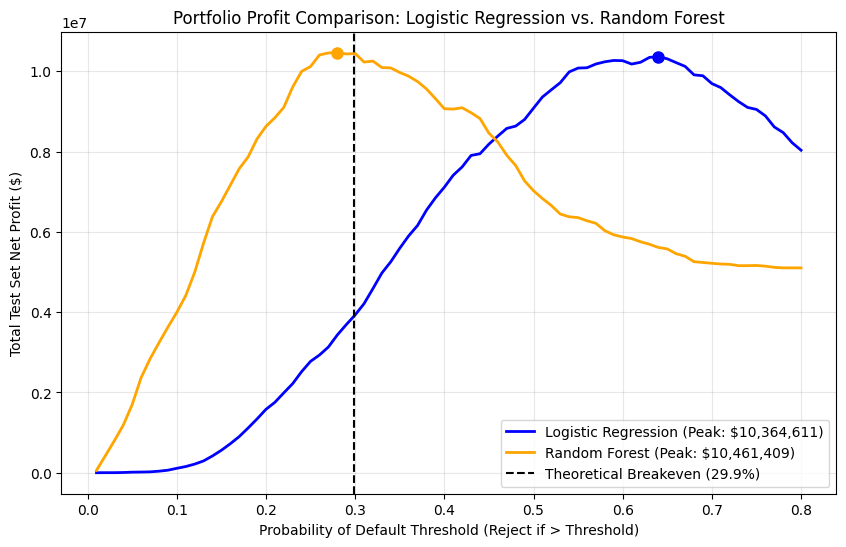

In [9]:
import matplotlib.pyplot as plt

thresholds = np.linspace(0.01, 0.8, 80)
lr_profits = []
rf_profits = []

for t in thresholds:
    # -- Logistic Regression --
    lr_mask = log_reg_preds["log_reg_prob"] <= t
    lr_profit = test_financials["net_pnl"][lr_mask].sum()
    lr_profits.append(lr_profit)

    # -- Random Forest --
    rf_mask = rf_preds["rf_prob"] <= t
    rf_profit = test_financials["net_pnl"][rf_mask].sum()
    rf_profits.append(rf_profit)

max_lr_profit = max(lr_profits)
best_lr_threshold = thresholds[lr_profits.index(max_lr_profit)]

max_rf_profit = max(rf_profits)
best_rf_threshold = thresholds[rf_profits.index(max_rf_profit)]

print(
    f"Logistic Regression Peak Profit: ${max_lr_profit:,.2f} (at threshold {best_lr_threshold*100:.1f}%)"
)
print(
    f"Random Forest Peak Profit: ${max_rf_profit:,.2f} (at threshold {best_rf_threshold*100:.1f}%)"
)

plt.figure(figsize=(10, 6))
plt.plot(
    thresholds,
    lr_profits,
    label=f"Logistic Regression (Peak: ${max_lr_profit:,.0f})",
    color="blue",
    linewidth=2,
)
plt.plot(
    thresholds,
    rf_profits,
    label=f"Random Forest (Peak: ${max_rf_profit:,.0f})",
    color="orange",
    linewidth=2,
)

plt.axvline(
    x=0.299, color="black", linestyle="--", label="Theoretical Breakeven (29.9%)"
)

plt.plot(best_lr_threshold, max_lr_profit, marker="o", color="blue", markersize=8)
plt.plot(best_rf_threshold, max_rf_profit, marker="o", color="orange", markersize=8)

plt.title("Portfolio Profit Comparison: Logistic Regression vs. Random Forest")
plt.xlabel("Probability of Default Threshold (Reject if > Threshold)")
plt.ylabel("Total Test Set Net Profit ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()